In [90]:
import xarray as xr
import numpy as np
import pandas as pd
import ast

In [119]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

In [ ]:
import psutil
import dask
from dask.distributed import Client
client = Client(
    n_workers=7
)
client

In [149]:
def assign_weatherfeature_coords(ds):
    # suqeeze
    ds = ds.squeeze()
    
    # get names of y and x dims
    y_dim = list(ds.dims)[1]
    x_dim = list(ds.dims)[2]
    
    # get numbers of y and x dims
    ny = ds.sizes[y_dim]
    nx = ds.sizes[x_dim]
    
    # assign coords
    lat_vals = np.arange(-90, 90.5, 0.5)
    lon_vals = -180 + 0.5 * np.arange(nx)
    ds = ds.assign_coords({y_dim: (y_dim, lat_vals)})
    ds = ds.assign_coords({x_dim: (x_dim, lon_vals)})
    
    # rename y- and x-coordiante as lat and lon
    ds = ds.rename({y_dim: 'latitude', x_dim: 'longitude'})

    # check longitude
    if ds.longitude.size != 720:
        ds = ds.sel(longitude=np.arange(-180, 180, .5))

    return ds

from scipy.ndimage import gaussian_filter
def gaussian_smooth_2d(da, sigma=1.0):
    smoothed = gaussian_filter(
        da.values,
        sigma=sigma,
        mode="nearest",
    )

    return xr.DataArray(
        smoothed,
        coords=da.coords,
        dims=da.dims,
        attrs=da.attrs,
        name=da.name,
    )

In [93]:
# directories
workdir = '/g/data/if69/cj0591/GC26_energy_synoptics'
datadir = f'{workdir}/data/weatherfeatures.era5'
era5dir = '/g/data/rt52/era5/single-levels'

In [195]:
df = pd.read_csv('/scratch/if69/pd1739/State_extreme_demand_dates.csv')
df["high_demand"] = df["high_demand"].apply(
    lambda x: pd.to_datetime(ast.literal_eval(x))
)
df["low_demand"] = df["low_demand"].apply(
    lambda x: pd.to_datetime(ast.literal_eval(x))
)
highdemand = df.loc[df["state"] == "QLD", "high_demand"].iloc[0]
lowdemand = df.loc[df["state"] == "QLD", "low_demand"].iloc[0]

In [170]:
from tqdm import tqdm

In [196]:
composite_list = []
for datesr in tqdm(lowdemand):
    year = str(datesr)[0:4]
    month = str(datesr)[5:7]
    day = str(datesr)[8:10]
    day_str = f'{year}-{month}-{day}'

    # fn
    F_fn = f"{datadir}/fronts/cdf.700hPa/{year}/F{year}_{str(month).zfill(2)}.nc"
    C_fn = f"{datadir}/mincl/cdf/{year}/C{year}_{str(month).zfill(2)}.nc"
    A_fn = f"{datadir}/maxcl/cdf/{year}/A{year}_{str(month).zfill(2)}.nc"
    W_fn = f"{datadir}/wcb/cdf.1hourly/{year}/hit_{year}_{str(month).zfill(2)}.nc"
    
    dsF = xr.open_dataset(F_fn)
    dsF = assign_weatherfeature_coords(dsF).sel(time=day_str)
    
    dsC = xr.open_dataset(C_fn)
    dsC = assign_weatherfeature_coords(dsC).sel(time=day_str)
    
    dsA = xr.open_dataset(A_fn)
    dsA = assign_weatherfeature_coords(dsA).sel(time=day_str)

    dsW = xr.open_dataset(W_fn)
    dsW = assign_weatherfeature_coords(dsW).sel(time=day_str)

    dsFeature = xr.merge([dsF['FRONT'], dsC['INPUT'], dsA['FLAG'],
                          dsW['GT800'], dsW['MIDTROP'], dsW['LT400']],
                         compat='override')
    dsFeature = dsFeature.sel(latitude=slice(-55, -9),longitude=slice(110, 155))
    dsFeature = dsFeature.mean('time').compute()
    composite_list.append(dsFeature)

# Low demand
dsFeature_low_compo = xr.concat(composite_list, dim='time')
dsFeature_low_compomean = dsFeature_low_compo.mean('time')

100%|██████████| 95/95 [00:49<00:00,  1.91it/s]


In [197]:
composite_list = []
for datesr in tqdm(highdemand):
    year = str(datesr)[0:4]
    month = str(datesr)[5:7]
    day = str(datesr)[8:10]
    day_str = f'{year}-{month}-{day}'

    # fn
    F_fn = f"{datadir}/fronts/cdf.700hPa/{year}/F{year}_{str(month).zfill(2)}.nc"
    C_fn = f"{datadir}/mincl/cdf/{year}/C{year}_{str(month).zfill(2)}.nc"
    A_fn = f"{datadir}/maxcl/cdf/{year}/A{year}_{str(month).zfill(2)}.nc"
    W_fn = f"{datadir}/wcb/cdf.1hourly/{year}/hit_{year}_{str(month).zfill(2)}.nc"
    
    dsF = xr.open_dataset(F_fn)
    dsF = assign_weatherfeature_coords(dsF).sel(time=day_str)
    
    dsC = xr.open_dataset(C_fn)
    dsC = assign_weatherfeature_coords(dsC).sel(time=day_str)
    
    dsA = xr.open_dataset(A_fn)
    dsA = assign_weatherfeature_coords(dsA).sel(time=day_str)

    dsW = xr.open_dataset(W_fn)
    dsW = assign_weatherfeature_coords(dsW).sel(time=day_str)

    dsFeature = xr.merge([dsF['FRONT'], dsC['INPUT'], dsA['FLAG'],
                          dsW['GT800'], dsW['MIDTROP'], dsW['LT400']],
                         compat='override')
    dsFeature = dsFeature.sel(latitude=slice(-55, -9),longitude=slice(110, 155))
    dsFeature = dsFeature.mean('time').compute()
    composite_list.append(dsFeature)

# High demand
dsFeature_high_compo = xr.concat(composite_list, dim='time')
dsFeature_high_compomean = dsFeature_high_compo.mean('time')

100%|██████████| 95/95 [00:49<00:00,  1.92it/s]


Text(0.5, 1.0, 'QLD | High Demand')

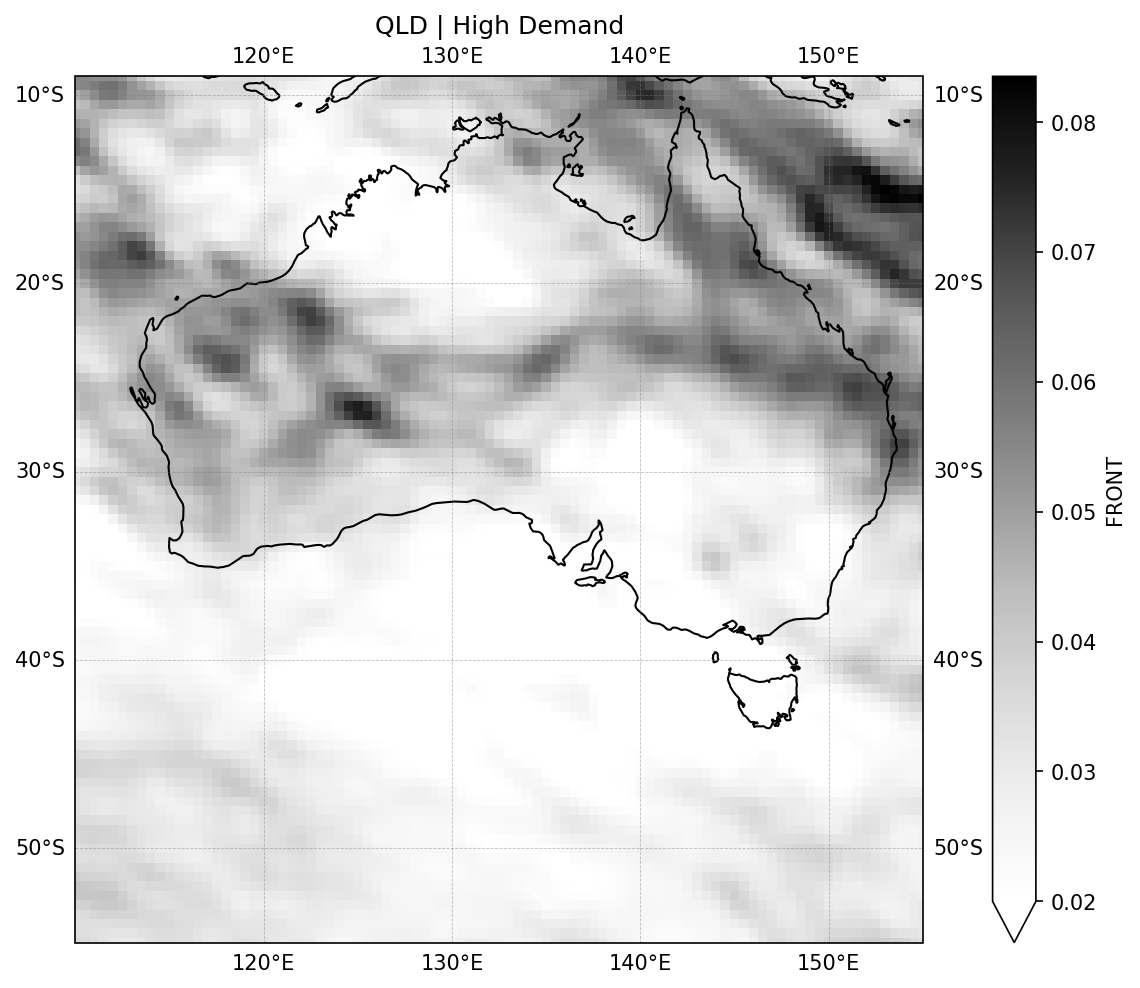

In [201]:
mapcrs  = ccrs.PlateCarree(central_longitude=120)
datacrs = ccrs.PlateCarree()

fig, ax = plt.subplots(
    figsize=(12, 7.5),
    dpi=150,
    facecolor="w",
    subplot_kw={"projection": mapcrs},
)

gaussian_smooth_2d(dsFeature_high_compomean['FRONT']).plot(ax=ax,vmin=0.02, cmap='Greys', transform=datacrs)
##gaussian_smooth_2d(dsFeature_high_compomean['INPUT']).plot.contour(ax=ax,colors='darkorange', levels=np.arange(0.05, 0.2+.02, .02), transform=datacrs)
#gaussian_smooth_2d(dsFeature_high_compomean['FLAG']).plot.contour(ax=ax,colors='r', levels=np.arange(0.2, 0.8+.1, .1), transform=datacrs)
#gaussian_smooth_2d(dsFeature_high_compomean['GT800']).plot.contour(ax=ax,colors='deeppink', levels=np.arange(0.05, 0.2+.02, .02), transform=datacrs)
#gaussian_smooth_2d(dsFeature_high_compomean['MIDTROP']).plot.contour(ax=ax,colors='purple', levels=np.arange(0.05, 0.2+.02, .02), transform=datacrs)
#gaussian_smooth_2d(dsFeature_high_compomean['LT400']).plot.contour(ax=ax,colors='green', levels=np.arange(0.05, 0.2+.02, .02), transform=datacrs)

ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="k", lw=1)
ax.set_extent([110, 155, -55, -9], crs=datacrs)
gl = ax.gridlines(
    crs=datacrs,
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
ax.set_title('QLD | High Demand')

Text(0.5, 1.0, 'QLD | Low Demand')

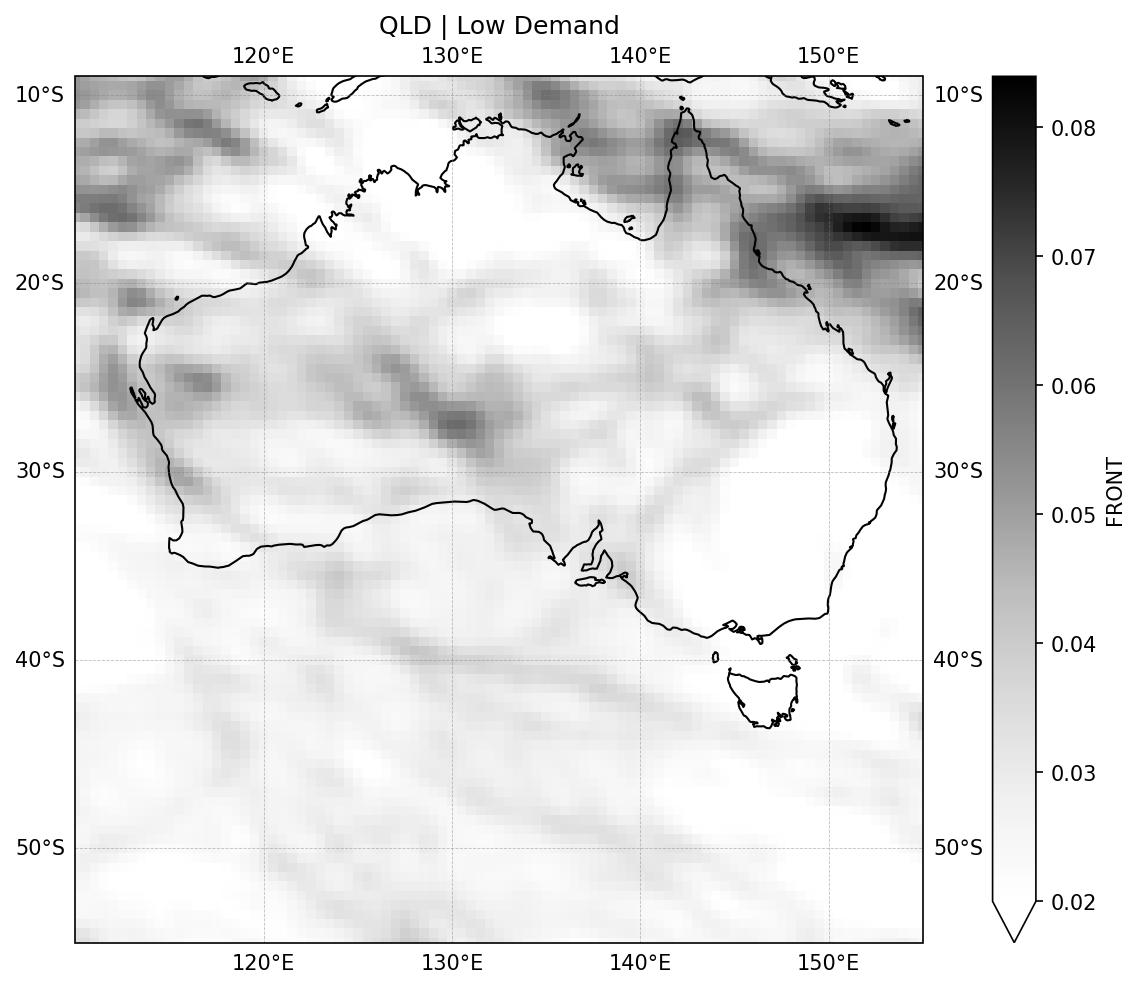

In [200]:
mapcrs  = ccrs.PlateCarree(central_longitude=120)
datacrs = ccrs.PlateCarree()

fig, ax = plt.subplots(
    figsize=(12, 7.5),
    dpi=150,
    facecolor="w",
    subplot_kw={"projection": mapcrs},
)

gaussian_smooth_2d(dsFeature_low_compomean['FRONT']).plot(ax=ax,vmin=0.02, cmap='Greys', transform=datacrs)
#gaussian_smooth_2d(dsFeature_low_compomean['INPUT']).plot.contour(ax=ax,colors='darkorange', levels=np.arange(0.05, 0.2+.02, .02), transform=datacrs)
#gaussian_smooth_2d(dsFeature_low_compomean['FLAG']).plot.contour(ax=ax,colors='r', levels=np.arange(0.2, 0.8+.1, .1), transform=datacrs)
#gaussian_smooth_2d(dsFeature_low_compomean['GT800']).plot.contour(ax=ax,colors='deeppink', levels=np.arange(0.05, 0.2+.02, .02), transform=datacrs)
#gaussian_smooth_2d(dsFeature_low_compomean['MIDTROP']).plot.contour(ax=ax,colors='purple', levels=np.arange(0.05, 0.2+.02, .02), transform=datacrs)
#gaussian_smooth_2d(dsFeature_low_compomean['LT400']).plot.contour(ax=ax,colors='green', levels=np.arange(0.05, 0.2+.02, .02), transform=datacrs)

ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="k", lw=1)
ax.set_extent([110, 155, -55, -9], crs=datacrs)
gl = ax.gridlines(
    crs=datacrs,
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
ax.set_title('QLD | Low Demand')